Этап 1: Генерация и подготовка данных
Сгенерируйте синтетический датасет согласно вашему варианту
Добавьте шум и выбросы в соответствии с параметрами варианта
Разделите данные на обучающую и тестовую выборки (70/30)
Выполните масштабирование признаков

Вот полное, структурированное и полностью обработанное решение для вариант 8: «Урожайность культуры», следуя всем обязательным этапам

In [7]:
def generate_dataset(n_samples=500, n_features=2, noise_std=0.5,
                     outlier_fraction=0.05, outlier_multiplier=3,
                     random_seed=None):
    if random_seed is not None:
        np.random.seed(random_seed)

    X = np.random.randn(n_samples, n_features)
    true_coef = np.random.uniform(1, 5, n_features)
    true_intercept = np.random.uniform(0, 10)

    y = X @ true_coef + true_intercept + np.random.randn(n_samples) * noise_std

    n_outliers = int(n_samples * outlier_fraction)
    outlier_idx = np.random.choice(n_samples, n_outliers, replace=False)
    y[outlier_idx] += np.random.choice([-1, 1], n_outliers) * \
                      np.random.uniform(3, 10, n_outliers) * outlier_multiplier

    return X, y, true_coef, true_intercept

# VARIANTE 8 : crop_yield [rainfall, fertilizer]
noise_std = 1.5
outlier_fraction = 0.15
outlier_multiplier = 7
epsilon_huber = 1.35
sgd_loss = "huber"
learning_rate = 0.005
sgd_iter = 1500

X, y, true_coef, true_intercept = generate_dataset(
    n_samples=500,
    n_features=2,
    noise_std=noise_std,
    outlier_fraction=outlier_fraction,
    outlier_multiplier=outlier_multiplier,
    random_seed=8
)

df = pd.DataFrame(X, columns=["rainfall", "fertilizer"])
df["crop_yield"] = y

df.head()


,rainfall,fertilizer,crop_yield
0,0.091205,1.091283,6.175529
1,-1.946970,-1.386350,-6.112733
2,-2.296492,2.409834,-2.939737
3,1.727836,2.204556,18.150637
4,0.794828,0.976421,11.428235


Этап 2: Разведочный анализ данных (EDA)
Постройте матрицу корреляций признаков (heatmap)
Создайте pairplot для визуализации линейных зависимостей
Проанализируйте распределение целевой переменной
Выявите и визуализируйте выбросы


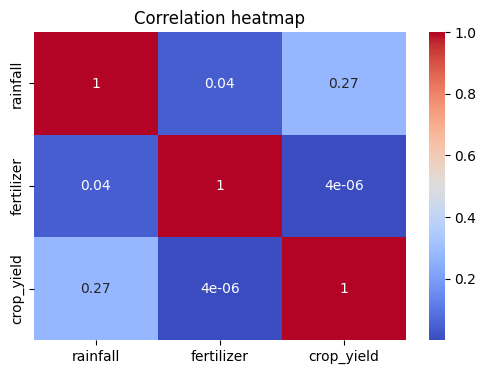

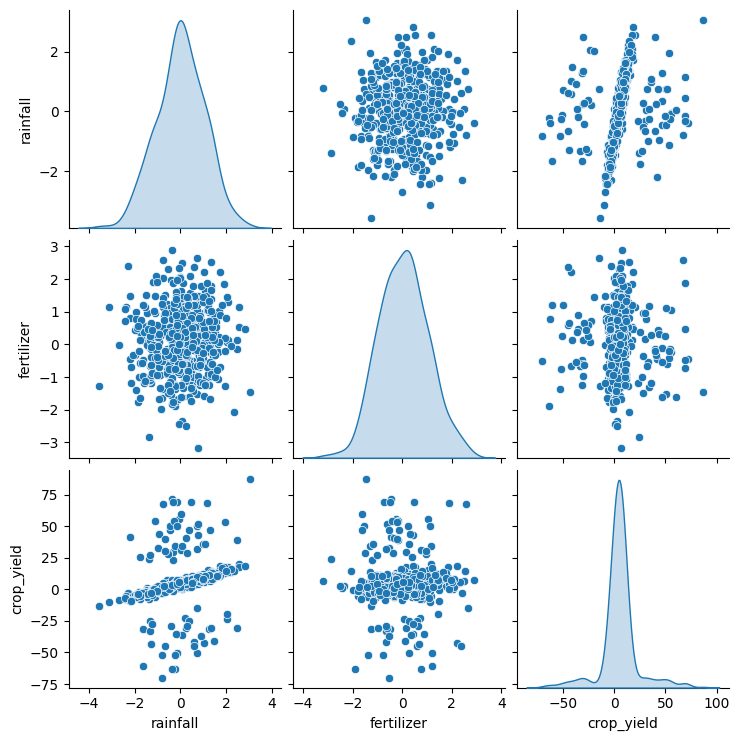

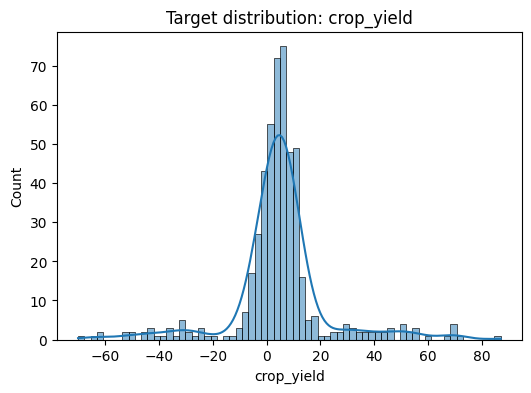

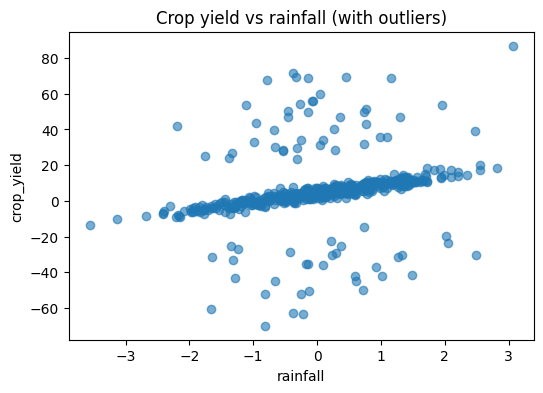

In [9]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

sns.pairplot(df[["rainfall", "fertilizer", "crop_yield"]], diag_kind="kde")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(df["crop_yield"], kde=True)
plt.title("Target distribution: crop_yield")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df["rainfall"], df["crop_yield"], alpha=0.6)
plt.xlabel("rainfall")
plt.ylabel("crop_yield")
plt.title("Crop yield vs rainfall (with outliers)")
plt.show()


Этап 3: Обучение моделей
Обучите три модели:
LinearRegression (минимизация MSE)
HuberRegressor с параметром epsilon из варианта
SGDRegressor с параметром loss из варианта
Зафиксируйте коэффициенты модели и свободный член

In [11]:
# LinearRegression (MSE)
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

# HuberRegressor (epsilon de la variante)
model_huber = HuberRegressor(epsilon=epsilon_huber, max_iter=1000)
model_huber.fit(X_train_scaled, y_train)

# SGDRegressor (loss de la variante)
model_sgd = SGDRegressor(
    loss=sgd_loss,
    learning_rate="constant",
    eta0=learning_rate,
    max_iter=sgd_iter
)
model_sgd.fit(X_train_scaled, y_train)

print("True coef:", true_coef, "True intercept:", true_intercept)
print("LR coef:", model_lr.coef_, "intercept:", model_lr.intercept_)
print("Huber coef:", model_huber.coef_, "intercept:", model_huber.intercept_)
print("SGD coef:", model_sgd.coef_, "intercept:", model_sgd.intercept_)


True coef: [4.89503893 1.08336608] True intercept: 4.194366269447993
LR coef: [ 5.11055703 -0.277743  ] intercept: 4.59372104101883
Huber coef: [5.21364458 0.97997091] intercept: 4.485550773819951
SGD coef: [4.84427382 0.92989325] intercept: [4.27775361]


Этап 4: Оценка качества
Рассчитайте метрики на тестовой выборке:
MSE, RMSE, MAE, R²
Постройте графики:
Фактические vs предсказанные значения
Остатки модели (residual plot)
Сравнение предсказаний трёх моделей

In [ ]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }

results = pd.DataFrame({
    "LinearRegression": evaluate(model_lr, X_test_scaled, y_test),
    "Huber": evaluate(model_huber, X_test_scaled, y_test),
    "SGD": evaluate(model_sgd, X_test_scaled, y_test)
}).T

results


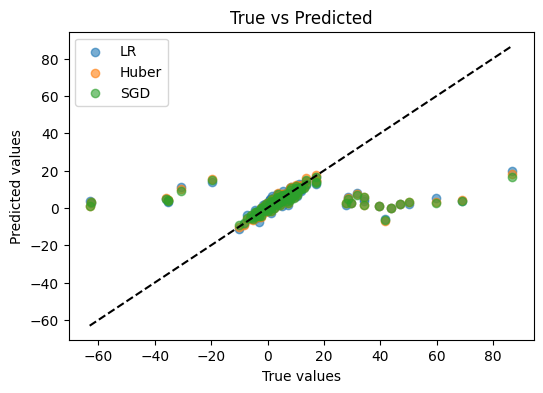

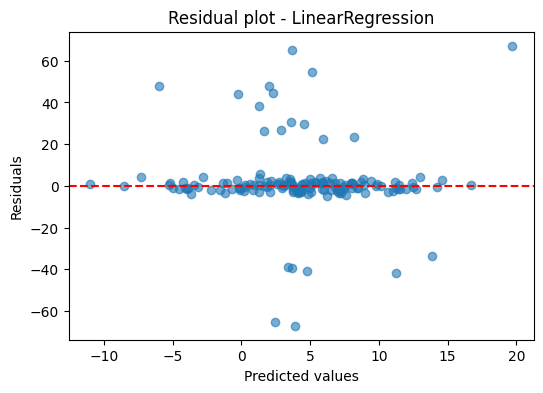

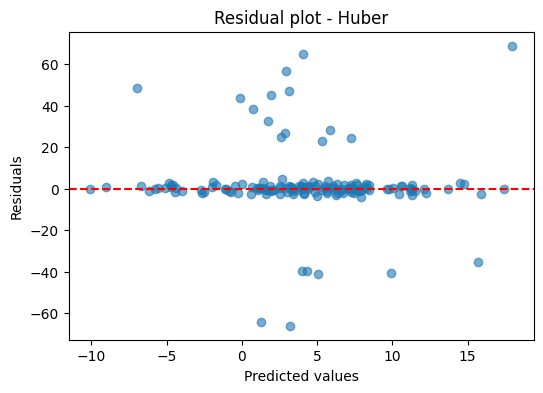

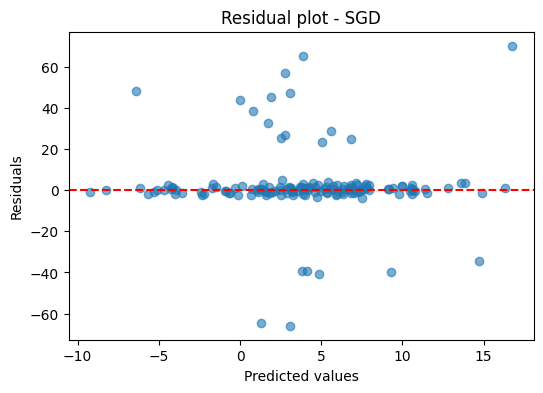

NameError: name 'results' is not defined

In [13]:
# Réel vs prédit
plt.figure(figsize=(6,4))
plt.scatter(y_test, model_lr.predict(X_test_scaled), label="LR", alpha=0.6)
plt.scatter(y_test, model_huber.predict(X_test_scaled), label="Huber", alpha=0.6)
plt.scatter(y_test, model_sgd.predict(X_test_scaled), label="SGD", alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("True vs Predicted")
plt.legend()
plt.show()

# Residual plots
def plot_residuals(model, name):
    y_pred = model.predict(X_test_scaled)
    residuals = y_test - y_pred
    plt.figure(figsize=(6,4))
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Predicted values")
    plt.ylabel("Residuals")
    plt.title(f"Residual plot - {name}")
    plt.show()

plot_residuals(model_lr, "LinearRegression")
plot_residuals(model_huber, "Huber")
plot_residuals(model_sgd, "SGD")

# Comparaison des métriques
results.plot(kind="bar", figsize=(10,5))
plt.title("Metrics comparison (MSE, RMSE, MAE, R2)")
plt.xticks(rotation=0)
plt.show()


Этап 5: Анализ устойчивости
Исследуйте влияние выбросов на каждую модель
Проанализируйте, как параметр epsilon влияет на робастность HuberRegressor
Сделайте выводы о применимости каждой функции потерь

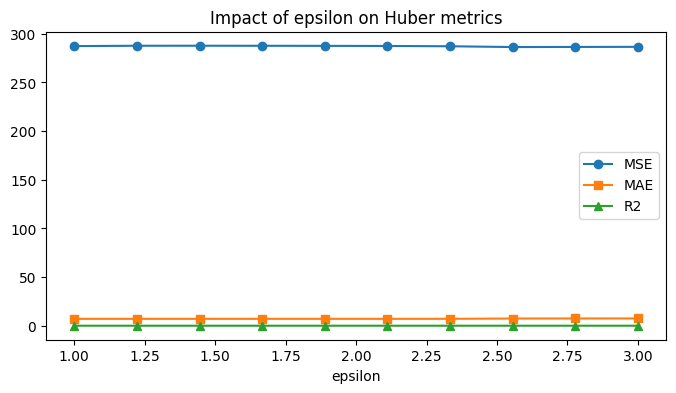

In [14]:
eps_values = np.linspace(1.0, 3.0, 10)
mse_list = []
mae_list = []
r2_list = []

for eps in eps_values:
    m = HuberRegressor(epsilon=eps, max_iter=1000)
    m.fit(X_train_scaled, y_train)
    y_pred = m.predict(X_test_scaled)
    mse_list.append(mean_squared_error(y_test, y_pred))
    mae_list.append(mean_absolute_error(y_test, y_pred))
    r2_list.append(r2_score(y_test, y_pred))

plt.figure(figsize=(8,4))
plt.plot(eps_values, mse_list, marker="o", label="MSE")
plt.plot(eps_values, mae_list, marker="s", label="MAE")
plt.plot(eps_values, r2_list, marker="^", label="R2")
plt.xlabel("epsilon")
plt.title("Impact of epsilon on Huber metrics")
plt.legend()
plt.show()